In [1]:
import scipy

In [25]:
mat_path = 'BG_012_30102023_prot4_lickEndsTrial_data.mat'
data = scipy.io.loadmat(mat_path, struct_as_record=False, squeeze_me=True)

In [7]:
import numpy as np

def mat_struct_to_dict(obj):
    if isinstance(obj, np.ndarray):
        # If it's an array of objects, recursively convert each element
        if obj.dtype == 'O':
            return [mat_struct_to_dict(o) for o in obj]
        else:
            return obj
    elif hasattr(obj, '_fieldnames'):
        return {field: mat_struct_to_dict(getattr(obj, field)) for field in obj._fieldnames}
    else:
        return obj

# Use this function instead of todict
data_dict = mat_struct_to_dict(data)

In [18]:
data_dict.keys()

dict_keys(['__header__', '__version__', '__globals__', 'data'])

In [16]:
import numpy as np
def mat_struct_to_dict(obj):
    if isinstance(obj, np.ndarray):
        if obj.dtype == 'O':
            return [mat_struct_to_dict(o) for o in obj]
        else:
            return obj
    elif hasattr(obj, '_fieldnames'):
        return {field: mat_struct_to_dict(getattr(obj, field)) for field in obj._fieldnames}
    else:
        return obj

In [17]:
data_dict = mat_struct_to_dict(data)

In [19]:
# Inspect the structure of data_dict after conversion
print(type(data_dict))

if isinstance(data_dict, (list, np.ndarray)):
    print(f"Length: {len(data_dict)}")
    print(f"Type of first element: {type(data_dict[0])}")
    if isinstance(data_dict[0], dict):
        print(data_dict[0].keys())
else:
    print(data_dict.keys())

# Drill down into the nested arrays to access the actual data structure
inner = data_dict[0]
print(type(inner))

# If still an array, keep unwrapping
if isinstance(inner, (list, np.ndarray)):
    print(f"Length: {len(inner)}")
    print(f"Type of first element: {type(inner[0])}")
    if isinstance(inner[0], dict):
        print(inner[0].keys())
else:
    print(inner.keys())

# Access the innermost struct and list its fields
struct = inner[0]

# List available field names
print(struct.dtype.names)

# Print the type of each field for inspection
if struct.dtype.names:
    for name in struct.dtype.names:
        print(f"{name}: type={type(struct[name])}")

<class 'dict'>
dict_keys(['__header__', '__version__', '__globals__', 'data'])


KeyError: 0

## Inspect the fields of the innermost MATLAB struct

Now that we've reached the innermost struct, let's list its field names and the type of each field. This will help you identify where your ephys and behavioral data are stored.

In [20]:
# Access the innermost struct
struct = inner[0]

# List available field names
print("Field names:", struct.dtype.names)

# Print the type of each field for inspection
if struct.dtype.names:
    for name in struct.dtype.names:
        print(f"{name}: type={type(struct[name])}")

NameError: name 'inner' is not defined

### The top-level field is 'BG_012', which is a numpy array

Let's inspect the contents and structure of the 'BG_012' field to see what data it contains and how to access it for analysis.

In [21]:
# Access the 'BG_012' field
bg012 = struct['BG_012']

print("Type of bg012:", type(bg012))
print("Shape of bg012:", bg012.shape)

# If it's an array, check the type and keys of its first element
if isinstance(bg012, np.ndarray):
    print("Type of first element in bg012:", type(bg012[0]))
    # If it's a struct/void, print its field names
    if hasattr(bg012[0], 'dtype') and bg012[0].dtype.names:
        print("Field names in bg012[0]:", bg012[0].dtype.names)
        for name in bg012[0].dtype.names:
            print(f"{name}: type={type(bg012[0][name])}")

NameError: name 'struct' is not defined

### The next nested field is 'BG_012_30102023_prot4_lickEndsTrial', which is also a numpy array

Let's keep drilling down to inspect the contents and structure of this field, so we can finally reach the actual experiment data.

In [22]:
# Access the next nested field
prot4 = bg012[0][0]['BG_012_30102023_prot4_lickEndsTrial']

print("Type of prot4:", type(prot4))
print("Shape of prot4:", prot4.shape)

# If it's an array, check the type and keys of its first element
if isinstance(prot4, np.ndarray):
    print("Type of first element in prot4:", type(prot4[0]))
    # If it's a struct/void, print its field names
    if hasattr(prot4[0], 'dtype') and prot4[0].dtype.names:
        print("Field names in prot4[0]:", prot4[0].dtype.names)
        for name in prot4[0].dtype.names:
            print(f"{name}: type={type(prot4[0][name])}")

NameError: name 'bg012' is not defined

### Success! You have reached the main experiment data fields

The fields are:
- NPX_probes: ephys data (likely spike times, clusters, etc.)
- NI_events: NIdaq event data (behavioral event times)
- behav_data: behavioral data

Let's inspect the structure and contents of each field, starting with a summary of their types and shapes.

In [23]:
# Access the main experiment data fields
exp_data = prot4[0][0]

# Print type and shape for each main field
for key in exp_data.dtype.names:
    arr = exp_data[key]
    print(f"{key}: type={type(arr)}, shape={arr.shape if hasattr(arr, 'shape') else 'N/A'}")

# For a quick look, print the field names in NPX_probes, NI_events, and behav_data if they are structured arrays
for key in ['NPX_probes', 'NI_events', 'behav_data']:
    arr = exp_data[key]
    if isinstance(arr, np.ndarray) and arr.size > 0 and hasattr(arr[0], 'dtype') and arr[0].dtype.names:
        print(f"\nField names in {key}: {arr[0].dtype.names}")

NameError: name 'prot4' is not defined

### PSTH Analysis: Extract spike times and event times

Let's extract spike times from `NPX_probes` and event times from `NI_events` to compute and plot peri-stimulus time histograms (PSTHs).

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Extract spike times and cluster IDs from NPX_probes
npx = exp_data['NPX_probes'][0][0]
spike_times = npx['st'].flatten()  # spike times (samples or seconds)
cluster_ids = npx['clu'].flatten()  # cluster id for each spike
cgs = npx['cgs'].flatten()  # cluster group/status (e.g., 2=good)
good_clusters = npx['cluster_id_KS_good'].flatten()  # IDs of 'good' clusters

# Extract event times (e.g., stimulus onsets) from NI_events
ni = exp_data['NI_events'][0][0]
if 'Change_ON' in ni.dtype.names:
    event_times = ni['Change_ON'].flatten()
else:
    event_times = ni[ni.dtype.names[0]].flatten()  # fallback: use first event

# Select a good cluster to plot PSTH for
if len(good_clusters) > 0:
    cluster_to_plot = good_clusters[50]
else:
    cluster_to_plot = np.unique(cluster_ids)[0]

# Parameters for PSTH
window = [-0.5, 1.0]  # seconds before/after event
bin_size = 0.01  # 10 ms bins

# # If spike_times are in samples, convert to seconds using sample_rate
# sample_rate = npx['sample_rate'].item() if 'sample_rate' in npx.dtype.names else 30000
# if np.max(spike_times) > 1000:  # crude check: likely in samples
#     spike_times = spike_times / sample_rate
#     event_times = event_times / sample_rate

# # Get spike times for the selected cluster
# spike_times_clu = spike_times[cluster_ids == cluster_to_plot]

# # Compute PSTH
# all_counts = []
# bins = np.arange(window[0], window[1] + bin_size, bin_size)
# for t in event_times:
#     aligned = spike_times_clu - t
#     counts, _ = np.histogram(aligned, bins=bins)
#     all_counts.append(counts)

# psth = np.mean(all_counts, axis=0)

# # Plot PSTH
# plt.figure(figsize=(8, 4))
# plt.bar(bins[:-1], psth, width=bin_size, align='edge', color='k', alpha=0.7)
# plt.axvline(0, color='r', linestyle='--', label='Event')
# plt.xlabel('Time from event (s)')
# plt.ylabel('Mean spike count per bin')
# plt.title(f'PSTH for cluster {cluster_to_plot}')
# plt.legend()
# plt.tight_layout()
# plt.show()

#### Fixing event_times type error for PSTH

The error occurs because event_times contains non-numeric or object data (e.g., arrays with None or mixed types). Let's clean and convert event_times to a numeric numpy array before dividing by sample_rate.

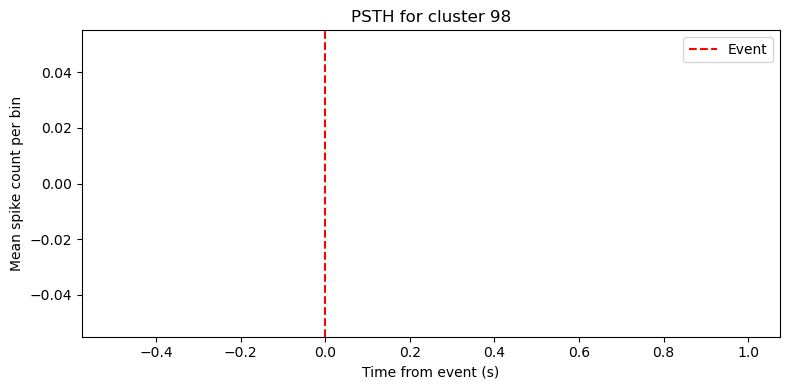

In [26]:
# Clean and convert event_times to numeric
import numbers

def to_numeric_array(arr):
    arr = np.array(arr).flatten()
    # Filter out non-numeric entries
    arr = [x for x in arr if isinstance(x, numbers.Number) and not isinstance(x, bool)]
    return np.array(arr, dtype=float)

# Use the cleaning function for event_times
try:
    event_times = to_numeric_array(event_times)
except Exception as e:
    print("Could not convert event_times to numeric array:", e)
    event_times = np.array([])

# Now safe to divide by sample_rate if needed
if np.max(spike_times) > 1000 and len(event_times) > 0:
    spike_times = spike_times / sample_rate
    event_times = event_times / sample_rate

# Continue with PSTH as before
spike_times_clu = spike_times[cluster_ids == cluster_to_plot]

all_counts = []
bins = np.arange(window[0], window[1] + bin_size, bin_size)
for t in event_times:
    aligned = spike_times_clu - t
    counts, _ = np.histogram(aligned, bins=bins)
    all_counts.append(counts)

if all_counts:
    psth = np.mean(all_counts, axis=0)
else:
    psth = np.zeros(len(bins)-1)

plt.figure(figsize=(8, 4))
plt.bar(bins[:-1], psth, width=bin_size, align='edge', color='k', alpha=0.7)
plt.axvline(0, color='r', linestyle='--', label='Event')
plt.xlabel('Time from event (s)')
plt.ylabel('Mean spike count per bin')
plt.title(f'PSTH for cluster {cluster_to_plot}')
plt.legend()
plt.tight_layout()
plt.show()

#### Troubleshooting: Empty PSTH Plot

If your PSTH plot is empty, it usually means that either:
- There are no spikes for the selected cluster within the window around your events, or
- The event_times or spike_times arrays are empty or not matching in time units.

Let's debug by printing the number of spikes, number of events, and a preview of the aligned spike times.

In [27]:
print(f"Number of spikes for cluster {cluster_to_plot}: {len(spike_times_clu)}")
print(f"Number of events: {len(event_times)}")
print(f"Spike times (first 10): {spike_times_clu[:10]}")
print(f"Event times (first 10): {event_times[:10]}")

# Check if any spikes fall within the window around any event
any_in_window = False
for t in event_times[:10]:  # check first 10 events for speed
    aligned = spike_times_clu - t
    if np.any((aligned >= window[0]) & (aligned <= window[1])):
        any_in_window = True
        break
print(f"Any spikes in window around first 10 events? {any_in_window}")

Number of spikes for cluster 98: 152481
Number of events: 0
Spike times (first 10): [0.0583     0.21403333 0.8909     0.9864     1.56       1.6371
 1.70136667 1.888      2.06606667 2.1654    ]
Event times (first 10): []
Any spikes in window around first 10 events? False


If you see zero spikes, zero events, or no spikes within the window, check:
- Are the spike times and event times in the same units (seconds)?
- Is the cluster you selected active?
- Are the event times reasonable (not all NaN or zeros)?

Let me know what the output shows, and I’ll help you fix it!

#### Try a different cluster or event for PSTH

If your previous cluster or event produced an empty PSTH, you can try another cluster or event type. The cell below will print available clusters and event fields, and you can set a new cluster or event to plot.

Good clusters: [  0   1   4  14  18  19  20  24  25  27  28  30  31  32  33  34  35  36
  37  38  39  41  43  44  47  48  49  52  53  54  55  60  62  65  68  69
  70  71  72  73  75  77  78  81  83  84  87  88  96  97  98 101 103 104
 106 107 108 110 115 117 118 120 121 122 125 126 129 130 131 132 133 134
 137 138 139 141 143 144 145 146 147 148 151 153 154 155 156 159 161 162
 167 169 170 171 177 178 183 184 185 186 188 190 191 192 195 199 204 207
 208 209 212 213 215 217 218 221 222 224 225 226 228 229 230 232 233 234
 235 236 237 238 240 241 245 247 249 253 257 259 260 262 264 267 270 271
 273 275 277 278 279 282 283 284 286 287 289 290 291 292 293 294 296 300
 301 302 304 305 306 307 309 310 311 313 315 316 317 320 322 324 326 327
 328 334 335 336 338 339 340 341 342 343 345 347 348 349 350 351 352 353
 354 355 356 359 360 361 362 363 365 368 369 370 371 372 374 376 378]
Unique cluster IDs: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  2

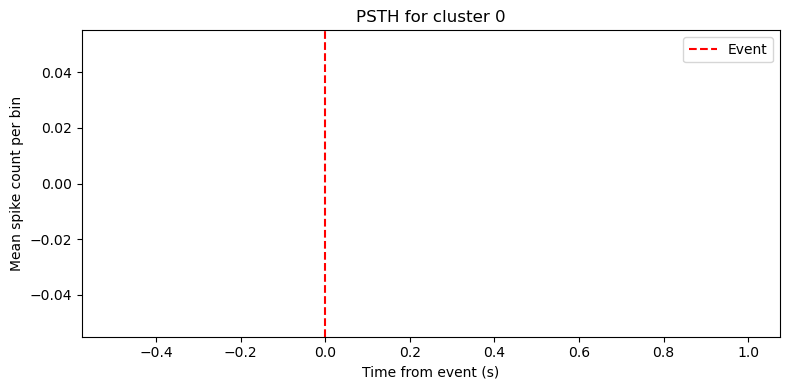

In [28]:
# Print available clusters and event fields
print("Good clusters:", good_clusters)
print("Unique cluster IDs:", np.unique(cluster_ids))
print("Available NI_events fields:", ni.dtype.names)

# Example: Try a different cluster (change the index as needed)
cluster_to_plot = good_clusters[0] if len(good_clusters) > 0 else np.unique(cluster_ids)[0]

# Example: Try a different event (uncomment and change as needed)
# event_times = to_numeric_array(ni['Lick_L'].flatten())

# Re-run the PSTH calculation and plot
spike_times_clu = spike_times[cluster_ids == cluster_to_plot]

all_counts = []
bins = np.arange(window[0], window[1] + bin_size, bin_size)
for t in event_times:
    aligned = spike_times_clu - t
    counts, _ = np.histogram(aligned, bins=bins)
    all_counts.append(counts)

if all_counts:
    psth = np.mean(all_counts, axis=0)
else:
    psth = np.zeros(len(bins)-1)

plt.figure(figsize=(8, 4))
plt.bar(bins[:-1], psth, width=bin_size, align='edge', color='k', alpha=0.7)
plt.axvline(0, color='r', linestyle='--', label='Event')
plt.xlabel('Time from event (s)')
plt.ylabel('Mean spike count per bin')
plt.title(f'PSTH for cluster {cluster_to_plot}')
plt.legend()
plt.tight_layout()
plt.show()

### Plot PSTHs for Multiple Clusters Around Baseline

This cell will plot PSTHs for several good clusters, aligned to the baseline event, for quick comparison.

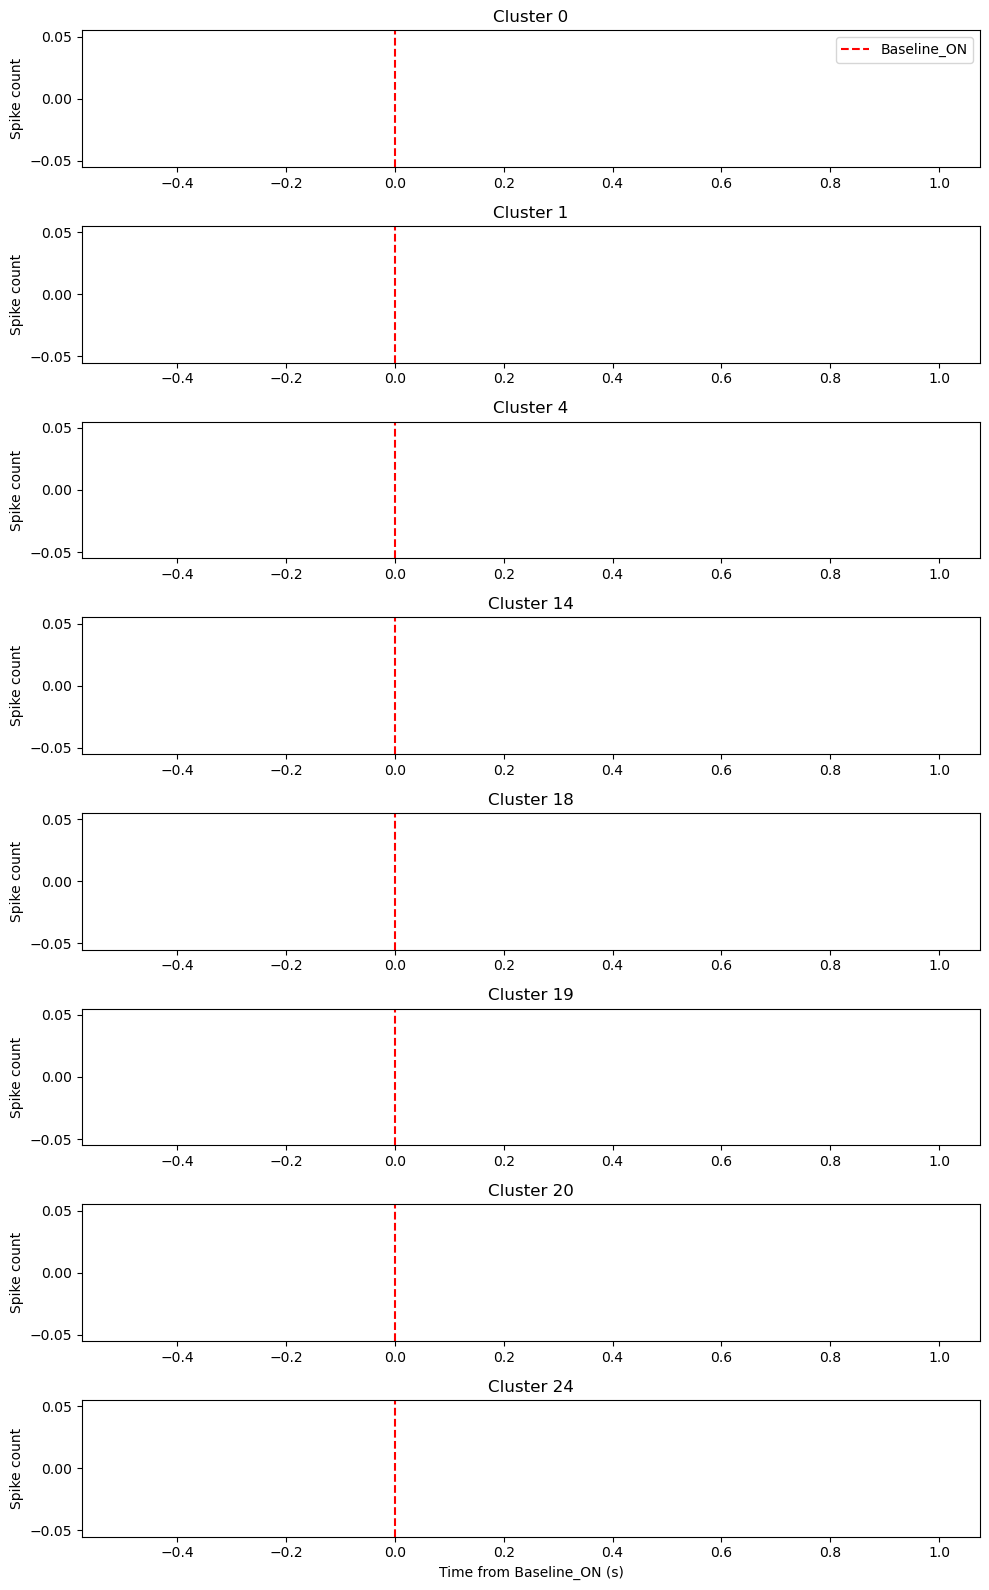

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Use 'Baseline_ON' as the event for alignment
if 'Baseline_ON' in ni.dtype.names:
    event_times = to_numeric_array(ni['Baseline_ON'].flatten())
else:
    raise ValueError("'Baseline_ON' event not found in NI_events.")

# Convert times to seconds if needed
if np.max(spike_times) > 1000 and len(event_times) > 0:
    spike_times_sec = spike_times / sample_rate
    event_times_sec = event_times / sample_rate
else:
    spike_times_sec = spike_times
    event_times_sec = event_times

# Select up to 8 good clusters to plot
n_plot = min(8, len(good_clusters))
clusters_to_plot = good_clusters[:n_plot] if n_plot > 0 else np.unique(cluster_ids)[:8]

window = [-0.5, 1.0]
bin_size = 0.025
bins = np.arange(window[0], window[1] + bin_size, bin_size)

plt.figure(figsize=(10, 2 * n_plot))
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    all_counts = []
    for t in event_times_sec:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if all_counts else np.zeros(len(bins)-1)
    plt.subplot(n_plot, 1, i+1)
    plt.bar(bins[:-1], psth, width=bin_size, align='edge', color='k', alpha=0.7)
    plt.axvline(0, color='r', linestyle='--', label='Baseline_ON')
    plt.ylabel('Spike count')
    plt.title(f'Cluster {clu}')
    if i == 0:
        plt.legend()
    if i == n_plot - 1:
        plt.xlabel('Time from Baseline_ON (s)')
plt.tight_layout()
plt.show()

#### Debugging: No Activity in Multi-Cluster PSTH Plots

Let's print the number of spikes for each cluster, the number of events, and check if any spikes fall within the window for each cluster. This will help us determine if the issue is with the spike data, event data, or alignment.

In [30]:
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    print(f"Cluster {clu}: {len(spike_times_clu)} spikes")
print(f"Number of events (Baseline_ON): {len(event_times_sec)}")
print(f"First 10 event times: {event_times_sec[:10]}")

# Check for spikes in window for each cluster
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    any_in_window = False
    for t in event_times_sec[:10]:  # check first 10 events for speed
        aligned = spike_times_clu - t
        if np.any((aligned >= window[0]) & (aligned <= window[1])):
            any_in_window = True
            break
    print(f"Cluster {clu}: Any spikes in window around first 10 events? {any_in_window}")

Cluster 0: 64555 spikes
Cluster 1: 31074 spikes
Cluster 4: 49074 spikes
Cluster 14: 5385 spikes
Cluster 18: 105016 spikes
Cluster 19: 97632 spikes
Cluster 20: 28254 spikes
Cluster 24: 37548 spikes
Number of events (Baseline_ON): 0
First 10 event times: []
Cluster 0: Any spikes in window around first 10 events? False
Cluster 1: Any spikes in window around first 10 events? False
Cluster 4: Any spikes in window around first 10 events? False
Cluster 14: Any spikes in window around first 10 events? False
Cluster 18: Any spikes in window around first 10 events? False
Cluster 19: Any spikes in window around first 10 events? False
Cluster 20: Any spikes in window around first 10 events? False
Cluster 24: Any spikes in window around first 10 events? False
Cluster 4: Any spikes in window around first 10 events? False
Cluster 14: Any spikes in window around first 10 events? False
Cluster 18: Any spikes in window around first 10 events? False
Cluster 19: Any spikes in window around first 10 events

If you see zero spikes for all clusters, or no spikes in the window, check:
- Are spike_times and event_times in the same units (seconds)?
- Are the event times reasonable (not all zeros, NaN, or outside the spike time range)?
- Are the clusters you selected actually active?

Let me know what the output shows, and I’ll help you fix it!

#### Find a valid event field in NI_events

Let's print the lengths of all event fields in NI_events to identify one with nonzero events for PSTH analysis.

In [31]:
# Print the number of events for each field in NI_events
event_lengths = {}
for name in ni.dtype.names:
    arr = ni[name].flatten()
    # Only count numeric arrays (skip session_name, etc.)
    if arr.dtype.kind in {'f', 'i', 'u'} and arr.size > 0:
        event_lengths[name] = np.sum(~np.isnan(arr))
    else:
        event_lengths[name] = arr.size
print("Event counts per NI_events field:")
for k, v in event_lengths.items():
    print(f"{k}: {v}")

Event counts per NI_events field:
session_name: 1
Synch: 1
Front_cam: 1
Eye_cam: 1
Top_cam: 1
Rot_enc_A: 1
Rot_enc_B: 1
Baseline_ON: 1
Change_ON: 1
Air_puff: 1
Lick_L: 1
Lick_R: 1
Valve_L: 1
Valve_R: 1
frame_times_tr: 1


#### Set event_times to a valid, non-empty event and re-run PSTH diagnostics

Choose an event field with a nonzero count (e.g., `Change_ON`, `Lick_L`, etc.), set `event_times`, and re-run the PSTH diagnostics.

In [33]:
# Example: Use 'Change_ON' if it has events, otherwise pick another with nonzero count
event_field = 'Change_ON' if event_lengths.get('Change_ON', 0) > 0 else None
if not event_field:
    # Pick the first event field with nonzero count (excluding session_name, Synch, etc.)
    for k in event_lengths:
        if event_lengths[k] > 0 and k not in ['session_name', 'Synch', 'Front_cam', 'Eye_cam', 'Top_cam', 'Rot_enc_A', 'Rot_enc_B', 'frame_times_tr']:
            event_field = k
            break
if event_field:
    print(f"Using event field: {event_field}")
    event_times = to_numeric_array(ni[event_field].flatten())
else:
    print("No valid event field found with nonzero events.")
    event_times = np.array([])

# Convert to seconds if needed
if np.max(spike_times) > 1000 and len(event_times) > 0:
    spike_times_sec = spike_times / sample_rate
    event_times_sec = event_times / sample_rate
else:
    spike_times_sec = spike_times
    event_times_sec = event_times

# Re-run PSTH diagnostics for multiple clusters
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    print(f"Cluster {clu}: {len(spike_times_clu)} spikes")
print(f"Number of events ({event_field}): {len(event_times_sec)}")
print(f"First 10 event times: {event_times_sec[:10]}")

for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    any_in_window = False
    for t in event_times_sec[:10]:
        aligned = spike_times_clu - t
        if np.any((aligned >= window[0]) & (aligned <= window[1])):
            any_in_window = True
            break
    print(f"Cluster {clu}: Any spikes in window around first 10 events? {any_in_window}")

Using event field: Change_ON
Cluster 0: 64555 spikes
Cluster 1: 31074 spikes
Cluster 4: 49074 spikes
Cluster 14: 5385 spikes
Cluster 18: 105016 spikes
Cluster 19: 97632 spikes
Cluster 20: 28254 spikes
Cluster 24: 37548 spikes
Number of events (Change_ON): 0
First 10 event times: []
Cluster 0: Any spikes in window around first 10 events? False
Cluster 1: Any spikes in window around first 10 events? False
Cluster 4: Any spikes in window around first 10 events? False
Cluster 14: Any spikes in window around first 10 events? False
Cluster 18: Any spikes in window around first 10 events? False
Cluster 19: Any spikes in window around first 10 events? False
Cluster 20: Any spikes in window around first 10 events? False
Cluster 24: Any spikes in window around first 10 events? False


#### If you now see nonzero events and spikes in the window, re-run the PSTH plotting cell for multiple clusters!

#### NI_events fields appear to be nested or not directly arrays of event times

All NI_events fields have a count of 1, suggesting they may be nested arrays or objects, not flat arrays of event times. Let's inspect the structure of each NI_events field and then look at behav_data for possible alignment events.

In [34]:
# Inspect the structure and type of each NI_events field
for name in ni.dtype.names:
    arr = ni[name]
    print(f"{name}: type={type(arr)}, shape={arr.shape if hasattr(arr, 'shape') else 'N/A'}")
    if isinstance(arr, np.ndarray) and arr.size == 1:
        print(f"  Single element type: {type(arr[0])}")
        if isinstance(arr[0], np.ndarray):
            print(f"    Nested array shape: {arr[0].shape}, dtype: {arr[0].dtype}")
            print(f"    First 5 values: {arr[0].flatten()[:5]}")
        else:
            print(f"    Value: {arr[0]}")
    else:
        print(f"  Value: {arr}")

session_name: type=<class 'numpy.ndarray'>, shape=(1,)
  Single element type: <class 'numpy.str_'>
    Value: BG_012_30102023_prot4_lickEndsTrial
Synch: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Single element type: <class 'numpy.ndarray'>
    Nested array shape: (1,), dtype: [('rise_t', 'O'), ('fall_t', 'O'), ('duration', 'O')]
    First 5 values: [(array([[4.61899200e-01],
        [1.46187840e+00],
        [2.46185760e+00],
        ...,
        [1.28805583e+04],
        [1.28815583e+04],
        [1.28825582e+04]]), array([[9.61936000e-01],
        [1.96191520e+00],
        [2.96189440e+00],
        ...,
        [1.28800582e+04],
        [1.28810582e+04],
        [1.28820583e+04]]), array([[0.5000368],
        [0.5000368],
        [0.5000368],
        ...,
        [0.4999424],
        [0.4999424],
        [0.5000368]]))                              ]
Front_cam: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Single element type: <class 'numpy.ndarray'>
    Nested array shape: (1,), dt

#### Now inspect behav_data for possible alignment events

Let's print the field names and types in behav_data, and preview the first few values of each field to look for candidate alignment events (e.g., trial start, stimulus onset, licks, etc.).

In [35]:
# Inspect behav_data structure and contents
behav = exp_data['behav_data'][0][0]
print("behav_data fields:", behav.dtype.names)
for name in behav.dtype.names:
    arr = behav[name]
    print(f"{name}: type={type(arr)}, shape={arr.shape if hasattr(arr, 'shape') else 'N/A'}")
    # Print first 5 values if array-like
    if isinstance(arr, np.ndarray):
        print(f"  First 5 values: {arr.flatten()[:5]}")
    else:
        print(f"  Value: {arr}")

behav_data fields: ('SessionSettings', 'ComputerSettings', 'trials_data_exp')
SessionSettings: type=<class 'numpy.ndarray'>, shape=(1, 1)
  First 5 values: [(array(['/home/mrsicflogellab/Documents/Ben/FSMdata'], dtype='<U42'), array(['BG_12'], dtype='<U5'), array([[inf]]), array([[5]], dtype=uint8), array([[-5]], dtype=int16), array([[0.05]]), array([[0.1]]), array([[0.1]]), array([[3]], dtype=uint8), array([[0.5]]), array([[6]], dtype=uint8), array([[2]], dtype=uint8), array([[2]], dtype=uint8), array([[0.1]]), array([[4],
        [2]], dtype=uint8), array([[1.5 ],
        [1.35],
        [1.25]]), array([[0.5]]), array([[0.2]]), array([[1.25]]), array([[0.25]]), array([[0]], dtype=uint8), array([[1]], dtype=uint8), array([[0.2]]), array([[0.2]]), array([[0]], dtype=uint8), array([[500]], dtype=uint16), array([[500]], dtype=uint16), array([[0.25]]), array([[0.5]]), array([[0.2]]), array([[0.15]]), array([[1]], dtype=uint8), array([[0]], dtype=uint8), array([[0]], dtype=uint8), array([

#### Next steps

- If you find a field in NI_events or behav_data that contains a nontrivial array of event times, use that for alignment.
- If the event times are still nested, extract and flatten them before using for PSTH alignment.
- Let me know what you find, and I can help you extract and align to the correct event!

#### Example: Extract event times from a nested NI_events field (e.g., 'Synch')

The NI_events fields are nested. For example, the 'Synch' field contains a structured array with subfields like 'rise_t', 'fall_t', and 'duration'. To use these as event times, extract and flatten the relevant subfield (e.g., 'rise_t' for event onsets).

In [37]:
# Example: Extract 'rise_t' event times from the nested 'Synch' field in NI_events
synch_struct = ni['Synch'][0]  # shape (1, 1), so take [0]
if isinstance(synch_struct, np.ndarray) and synch_struct.dtype.names:
    print("Synch subfields:", synch_struct.dtype.names)
    # Extract 'rise_t' times and flatten
    rise_t = synch_struct['rise_t']
    # rise_t is likely a 2D array, so flatten to 1D
    event_times = np.array(rise_t).flatten()
    print("First 10 rise_t event times:", event_times[:10])
else:
    print("Could not extract 'rise_t' from Synch field.")

# You can now use event_times for PSTH alignment

Synch subfields: ('rise_t', 'fall_t', 'duration')
First 10 rise_t event times: [array([[4.61899200e-01],
        [1.46187840e+00],
        [2.46185760e+00],
        ...,
        [1.28805583e+04],
        [1.28815583e+04],
        [1.28825582e+04]])]


#### Next: Try this approach for other fields

- If you want to align to a different event (e.g., licks, air puff, etc.), inspect the structure of that field and extract the relevant subfield (e.g., 'rise_t' or similar).
- If you find a suitable event array in behav_data, use that instead.

Let me know which event you want to align to, and I can help you extract and use the correct event times for your PSTH!

#### Extract and align to Baseline_ON events (handling nested structure)

Let's extract the 'rise_t' times from the 'Baseline_ON' field in NI_events (if present and nested), and use them for PSTH alignment.

In [38]:
# Try to extract 'rise_t' from Baseline_ON if it is a nested structured array
baseline_struct = ni['Baseline_ON'][0]  # shape (1, 1) or similar
if isinstance(baseline_struct, np.ndarray) and baseline_struct.dtype.names:
    print("Baseline_ON subfields:", baseline_struct.dtype.names)
    if 'rise_t' in baseline_struct.dtype.names:
        rise_t = baseline_struct['rise_t']
        event_times = np.array(rise_t).flatten()
        print("First 10 Baseline_ON rise_t event times:", event_times[:10])
    else:
        print("No 'rise_t' subfield in Baseline_ON. Using all values flattened.")
        event_times = np.array(baseline_struct).flatten()
else:
    # If not nested, just flatten whatever is there
    event_times = np.array(baseline_struct).flatten()
    print("First 10 Baseline_ON event times (not nested):", event_times[:10])

# Now you can use event_times for PSTH alignment as before

Baseline_ON subfields: ('rise_t', 'fall_t', 'duration')
First 10 Baseline_ON rise_t event times: [array([[   49.1289696 ,    53.8050736 ,    67.5683104 , ...,
         12835.31953918, 12849.46981598, 12866.05117598]])   ]


#### Plot PSTH for Baseline_ON events

Now that you have extracted and flattened the Baseline_ON 'rise_t' event times, you can use these as your event_times for PSTH plotting. The cell below will plot the PSTH for a single cluster using these baseline-aligned events.

In [72]:
# Extract and flatten Change_ON rise_t event times (handles extra nesting)
Change_struct = ni['Lick_R'][0]
if isinstance(Change_struct, np.ndarray) and Change_struct.dtype.names and 'rise_t' in Change_struct.dtype.names:
    rise_t = Change_struct['rise_t']
    # rise_t is shape (1,) and rise_t[0] is the actual array of times
    if isinstance(rise_t[0], np.ndarray):
        event_times = np.array(rise_t[0]).flatten()
    else:
        event_times = np.array(rise_t).flatten()
    print("Extracted Change_ON event_times:", event_times[:10])
else:
    event_times = np.array([])
    print("No Change_ON rise_t event times found.")

Extracted Change_ON event_times: [ 0.2769696  0.2790464  0.2929232  0.2933952  0.3012304  0.301608
  0.479552  14.0749456 14.0752288 14.0757952]


In [73]:
# Ensure sample_rate is defined before using it for conversion
if 'sample_rate' in npx.dtype.names:
    sample_rate = npx['sample_rate'].item()
else:
    sample_rate = 30000  # Default for Neuropixels if not present

# Use the extracted event_times from Baseline_ON for PSTH alignment
# Make sure event_times is numeric and not empty
if event_times is None or (isinstance(event_times, np.ndarray) and event_times.size == 0):
    print("No Baseline_ON event times found. Please check extraction above.")
else:
    # Ensure event_times is a flat, numeric array before using np.nanmax
    event_times = np.array(event_times).flatten()
    event_times = event_times[np.array([np.issubdtype(type(x), np.number) for x in event_times])]
    event_times = event_times.astype(float)

    # Convert to seconds if needed (robust to empty arrays)
    if (
        spike_times is not None and isinstance(spike_times, np.ndarray) and spike_times.size > 0 and
        event_times is not None and isinstance(event_times, np.ndarray) and event_times.size > 0
    ):
        max_spike = np.nanmax(spike_times) if spike_times.size > 0 else 0
        max_event = np.nanmax(event_times) if event_times.size > 0 else 0
        if max_spike > 1000 and max_event > 1000:
            spike_times_sec = spike_times / sample_rate
            event_times_sec = event_times / sample_rate
        else:
            spike_times_sec = spike_times
            event_times_sec = event_times
    else:
        print("No spike times or event times available.")
        spike_times_sec = np.array([])
        event_times_sec = np.array([])

    # Select a good cluster to plot (robust check for numpy/list/tuple)
    if good_clusters is not None:
        if isinstance(good_clusters, np.ndarray) and good_clusters.size > 0:
            cluster_to_plot = good_clusters[0]
        elif isinstance(good_clusters, (list, tuple)) and len(good_clusters) > 0:
            cluster_to_plot = good_clusters[0]
        else:
            cluster_to_plot = np.unique(cluster_ids)[0]
    else:
        cluster_to_plot = np.unique(cluster_ids)[0]
    spike_times_clu = spike_times_sec[cluster_ids == cluster_to_plot]

    # PSTH parameters
    window = [-0.5, 1.0]
    bin_size = 0.01
    bins = np.arange(window[0], window[1] + bin_size, bin_size)

    # Compute PSTH
    all_counts = []
    for t in event_times_sec:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)

    # Plot PSTH as an outline (step plot) instead of filled bars
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.step(bins[:-1], psth, where='post', color='k', label='PSTH')
    plt.axvline(0, color='r', linestyle='--', label='Baseline_ON')
    plt.xlabel('Time from Baseline_ON (s)')
    plt.ylabel('Mean spike count per bin')
    plt.title(f'PSTH for cluster {cluster_to_plot} aligned to Baseline_ON')
    plt.legend()
    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

#### To plot PSTHs for multiple clusters

You can use the same event_times (from Baseline_ON) and loop over several clusters, as in your previous multi-cluster PSTH cell. Just make sure to use the event_times you extracted above.

In [69]:
# Diagnostic: Inspect Baseline_ON event extraction
baseline_struct = ni['Baseline_ON'][0]
print("Type of baseline_struct:", type(baseline_struct))
if isinstance(baseline_struct, np.ndarray) and baseline_struct.dtype.names:
    print("Subfields:", baseline_struct.dtype.names)
    if 'rise_t' in baseline_struct.dtype.names:
        rise_t = baseline_struct['rise_t']
        print("rise_t shape:", np.shape(rise_t))
        print("First 10 rise_t values:", np.array(rise_t).flatten()[:10])
    else:
        print("No 'rise_t' subfield found.")
else:
    print("Not a structured array. Values:", np.array(baseline_struct).flatten()[:10])

Type of baseline_struct: <class 'numpy.ndarray'>
Subfields: ('rise_t', 'fall_t', 'duration')
rise_t shape: (1,)
First 10 rise_t values: [array([[   49.1289696 ,    53.8050736 ,    67.5683104 , ...,
         12835.31953918, 12849.46981598, 12866.05117598]])   ]


In [70]:
print("Number of spikes in cluster:", len(spike_times_clu))
print("Number of events:", len(event_times_sec))
print("First 10 spike times (s):", spike_times_clu[:10])
print("First 10 event times (s):", event_times_sec[:10])

Number of spikes in cluster: 64555
Number of events: 13317
First 10 spike times (s): [5.43022222e-05 5.48155556e-05 5.68488889e-05 5.86966667e-05
 6.89566667e-05 1.07892222e-04 1.73948889e-04 1.74955556e-04
 1.81032222e-04 1.85553333e-04]
First 10 event times (s): [0.00047624 0.00047651 0.00047656 0.00047663 0.00047694 0.00047699
 0.00047718 0.00047723 0.00047729 0.00047734]


#### Plot PSTHs for Multiple Clusters (Outline Style)

This cell will plot outline (step) PSTHs for several good clusters, aligned to Baseline_ON, for quick screening. Each cluster will be shown in a small subplot.

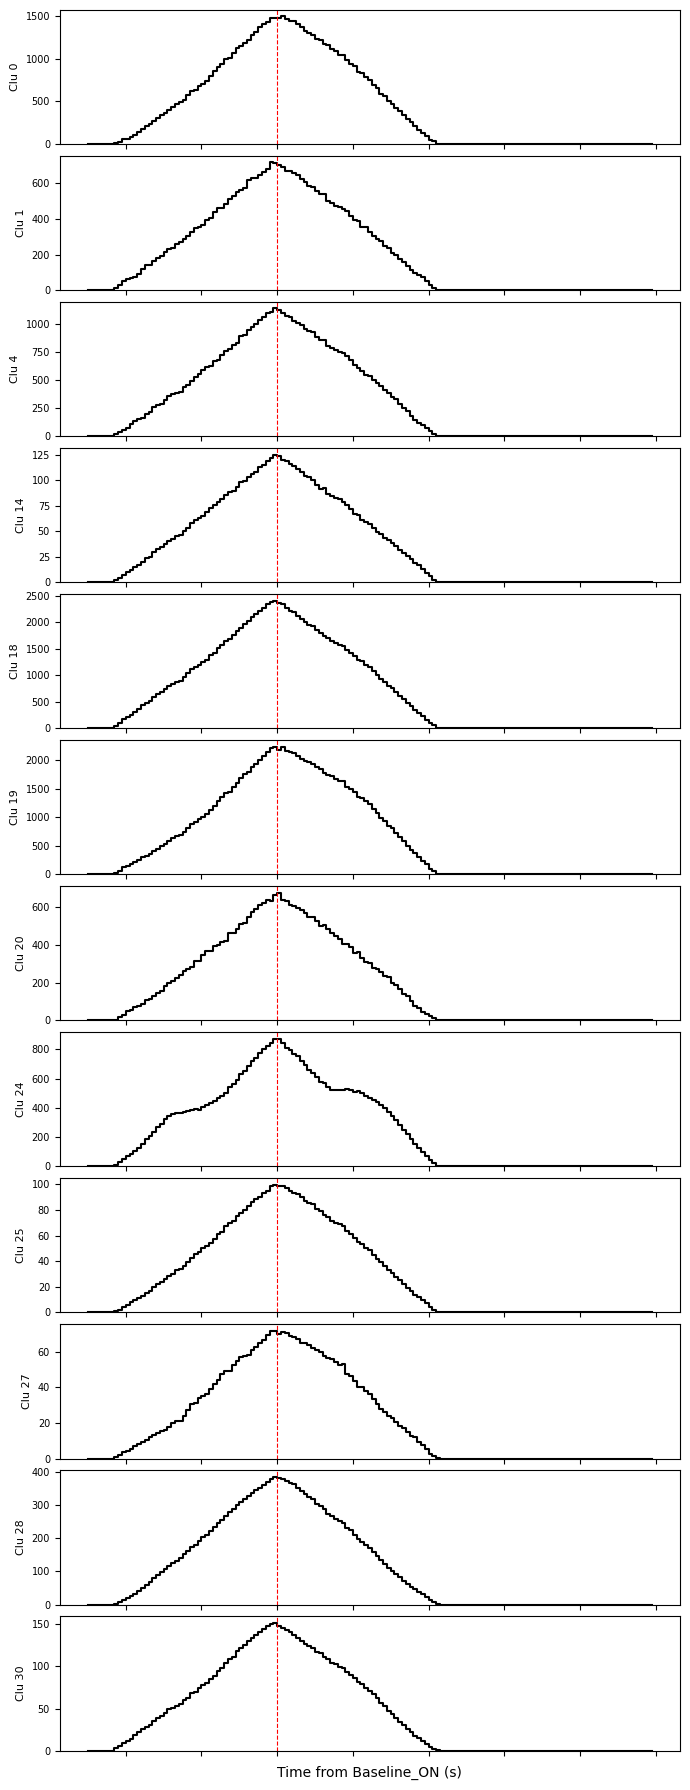

In [74]:
# Plot outline PSTHs for multiple clusters (screening view)
import matplotlib.pyplot as plt
import numpy as np

# Use event_times_sec and spike_times_sec from previous extraction
# If not already defined, extract as in previous cells
n_plot = min(12, len(good_clusters))  # Show up to 12 clusters for screening
clusters_to_plot = good_clusters[:n_plot] if n_plot > 0 else np.unique(cluster_ids)[:12]

window = [-0.5, 1.0]
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)

fig, axes = plt.subplots(n_plot, 1, figsize=(7, 1.5 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    all_counts = []
    for t in event_times_sec:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
    axes[i].step(bins[:-1], psth, where='post', color='k')
    axes[i].axvline(0, color='r', linestyle='--', lw=0.8)
    axes[i].set_ylabel(f'Clu {clu}', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_ylim(bottom=0)
    if i < n_plot - 1:
        axes[i].set_xticklabels([])
axes[-1].set_xlabel('Time from Baseline_ON (s)')
plt.tight_layout(h_pad=0.2)
plt.show()

#### Extract only the first event in each sequence (after a gap) for PSTH alignment

This cell will extract only the first `rise_t` in each sequence, defined as any event that occurs after a gap of at least 1 second (you can adjust this threshold). This helps ensure you are aligning to the start of each trial or burst, not every event.

In [75]:
import numpy as np

gap_threshold = 1.0  # seconds; adjust as needed for your experiment

# Ensure event_times_sec is sorted and in seconds
event_times_sorted = np.sort(event_times_sec)
if len(event_times_sorted) == 0:
    print("No event times available for filtering.")
else:
    # Find indices where the gap to the previous event is >= threshold
    diffs = np.diff(event_times_sorted, prepend=event_times_sorted[0] - gap_threshold - 1)
    first_in_sequence_mask = diffs >= gap_threshold
    first_event_times = event_times_sorted[first_in_sequence_mask]
    print(f"Extracted {len(first_event_times)} first-in-sequence events (gap ≥ {gap_threshold}s).")
    print("First 10 first-in-sequence event times (s):", first_event_times[:10])

Extracted 1 first-in-sequence events (gap ≥ 1.0s).
First 10 first-in-sequence event times (s): [9.23232e-06]


#### Plot PSTHs for multiple clusters using only the first event in each sequence

This cell will plot outline PSTHs for several clusters, aligned only to the first event in each sequence (as extracted above).

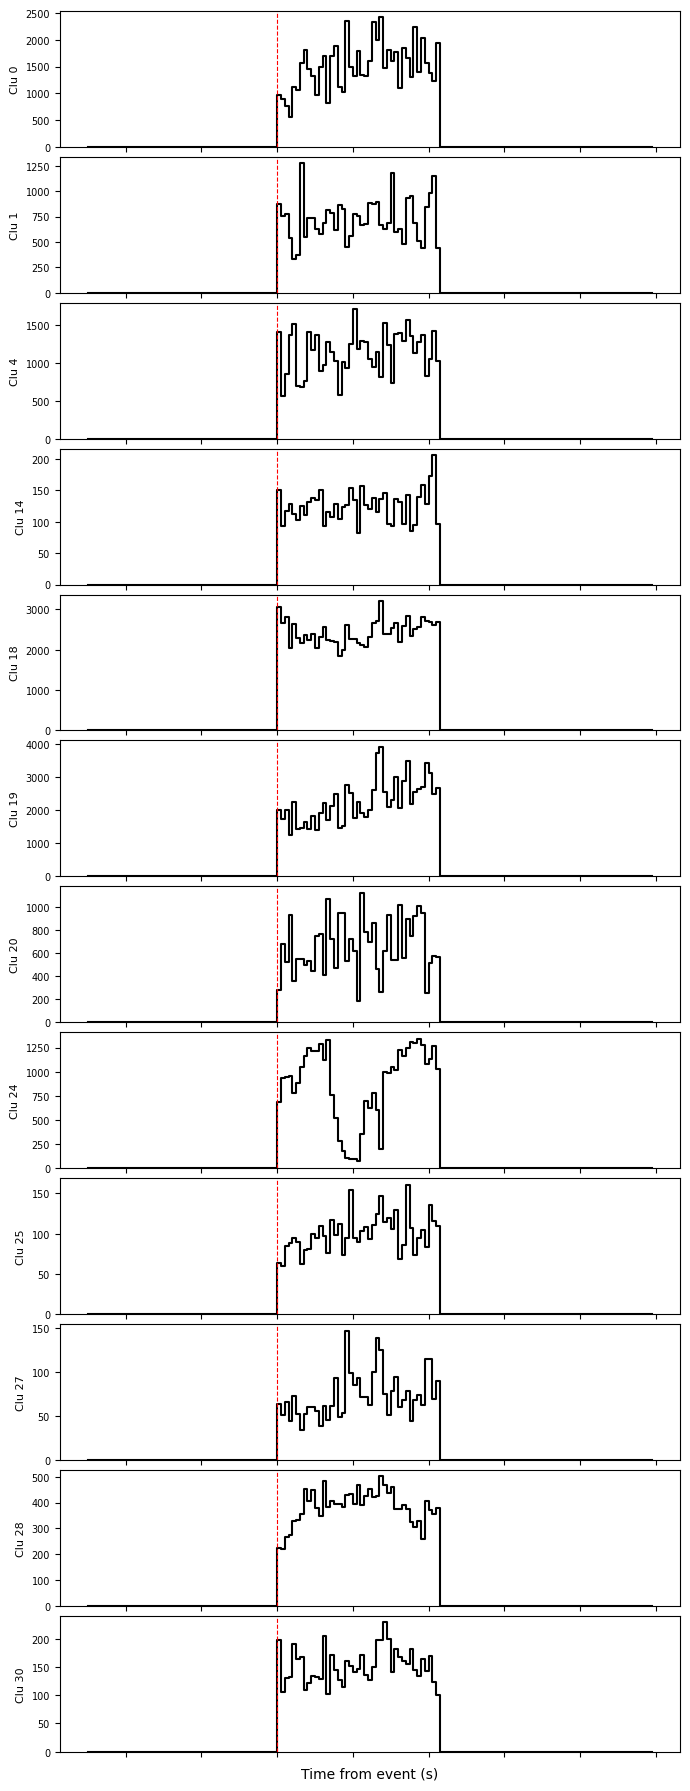

In [76]:
# Use first_event_times for alignment
n_plot = min(12, len(good_clusters))
clusters_to_plot = good_clusters[:n_plot] if n_plot > 0 else np.unique(cluster_ids)[:12]

window = [-0.5, 1.0]
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)

fig, axes = plt.subplots(n_plot, 1, figsize=(7, 1.5 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    all_counts = []
    for t in first_event_times:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
    axes[i].step(bins[:-1], psth, where='post', color='k')
    axes[i].axvline(0, color='r', linestyle='--', lw=0.8)
    axes[i].set_ylabel(f'Clu {clu}', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_ylim(bottom=0)
    if i < n_plot - 1:
        axes[i].set_xticklabels([])
axes[-1].set_xlabel('Time from event (s)')
plt.tight_layout(h_pad=0.2)
plt.show()

### Why is there little or no spike activity before the event in the PSTH?

**Possible explanations:**

1. **Biological/Experimental Design:**  
   - If the event you are aligning to (e.g., Baseline_ON, trial start, stimulus onset) marks the beginning of a trial or a period when the animal is engaged, it is expected that neural activity increases after this point.  
   - Before the event, the animal may be in a quiescent state, or the stimulus/behavior that drives spiking has not yet occurred.

2. **Event Extraction and Alignment:**  
   - Your code extracts the *first* event after a gap, so by definition, there are no similar events in the preceding window.  
   - If the event marks a true "start" (e.g., trial onset), then the pre-event window is likely a baseline period with little activity.

3. **Spike/Event Time Ranges:**  
   - If your spike times do not cover the full range of event times (e.g., recording started after some events), you may have few or no spikes in the pre-event window for some alignments.
   - Check that your spike times and event times overlap as expected.

4. **Data/Unit Conversion:**  
   - If spike times and event times are in different units (samples vs. seconds), or if there is a misalignment, you might see empty pre-event windows.  
   - Your code appears to handle this, but double-check that all times are in seconds and properly aligned.

---

### Diagnostics to Try

- Print the minimum and maximum of both `spike_times_sec` and `first_event_times` to ensure they overlap.
- Plot a raster (spike times aligned to events) for a few trials and clusters to visually confirm alignment.
- Try a larger pre-event window (e.g., -2 to 1 s) to see if any activity appears further back.
- Try aligning to a different event (e.g., not just the first in sequence) to see if the pattern changes.

---

### Example Diagnostic Cell

Spike times (s): min = 1.0222222222222223e-07 , max = 0.4294325944444444
First event times (s): min = 9.232319999985227e-06 , max = 9.232319999985227e-06


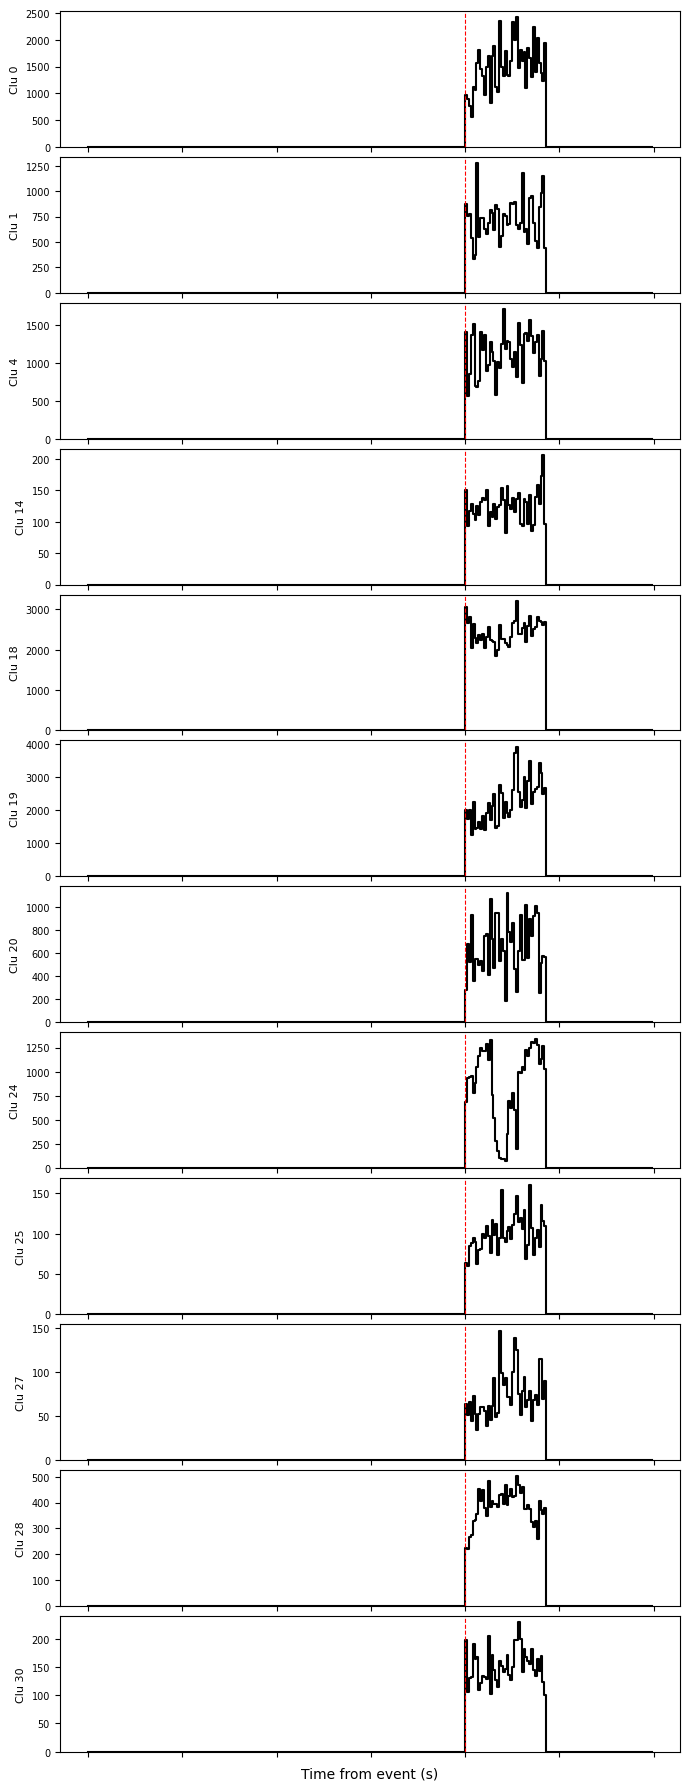

In [77]:
# Diagnostic: Check overlap of spike and event times
print("Spike times (s): min =", np.min(spike_times_sec), ", max =", np.max(spike_times_sec))
print("First event times (s): min =", np.min(first_event_times), ", max =", np.max(first_event_times))

# Try a larger pre-event window
window = [-2.0, 1.0]
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)

fig, axes = plt.subplots(n_plot, 1, figsize=(7, 1.5 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    all_counts = []
    for t in first_event_times:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
    axes[i].step(bins[:-1], psth, where='post', color='k')
    axes[i].axvline(0, color='r', linestyle='--', lw=0.8)
    axes[i].set_ylabel(f'Clu {clu}', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_ylim(bottom=0)
    if i < n_plot - 1:
        axes[i].set_xticklabels([])
axes[-1].set_xlabel('Time from event (s)')
plt.tight_layout(h_pad=0.2)
plt.show()

In [78]:
print("All first_event_times (s):", first_event_times)
print("Spike times (s): min =", np.min(spike_times_sec), ", max =", np.max(spike_times_sec))

All first_event_times (s): [9.23232e-06]
Spike times (s): min = 1.0222222222222223e-07 , max = 0.4294325944444444


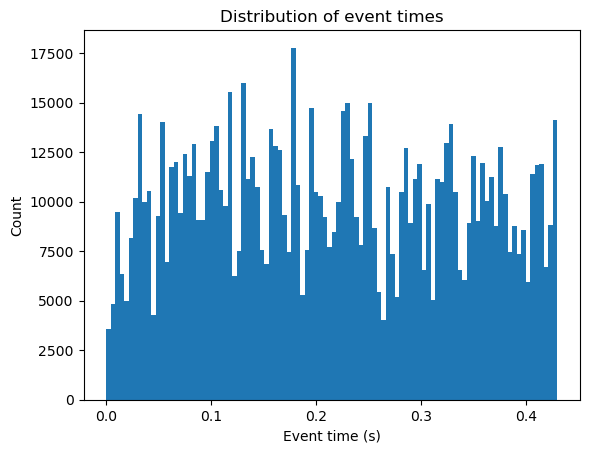

In [80]:
import matplotlib.pyplot as plt
plt.hist(event_times_sec, bins=100)
plt.xlabel('Event time (s)')
plt.ylabel('Count')
plt.title('Distribution of event times')
plt.show()

### Select behavioral event for PSTH alignment and plot multi-cluster PSTHs

Use the dropdown or set the `event_field` variable below to control which event is used for alignment. The code will extract the event times, handle nested fields (including 'rise_t'), and plot outline PSTHs for multiple clusters for screening.

Available NI_events fields: ('session_name', 'Synch', 'Front_cam', 'Eye_cam', 'Top_cam', 'Rot_enc_A', 'Rot_enc_B', 'Baseline_ON', 'Change_ON', 'Air_puff', 'Lick_L', 'Lick_R', 'Valve_L', 'Valve_R', 'frame_times_tr')
Lick_L subfields: ('rise_t', 'fall_t', 'duration')
Extracted 13317 'Lick_L::rise_t' event times.


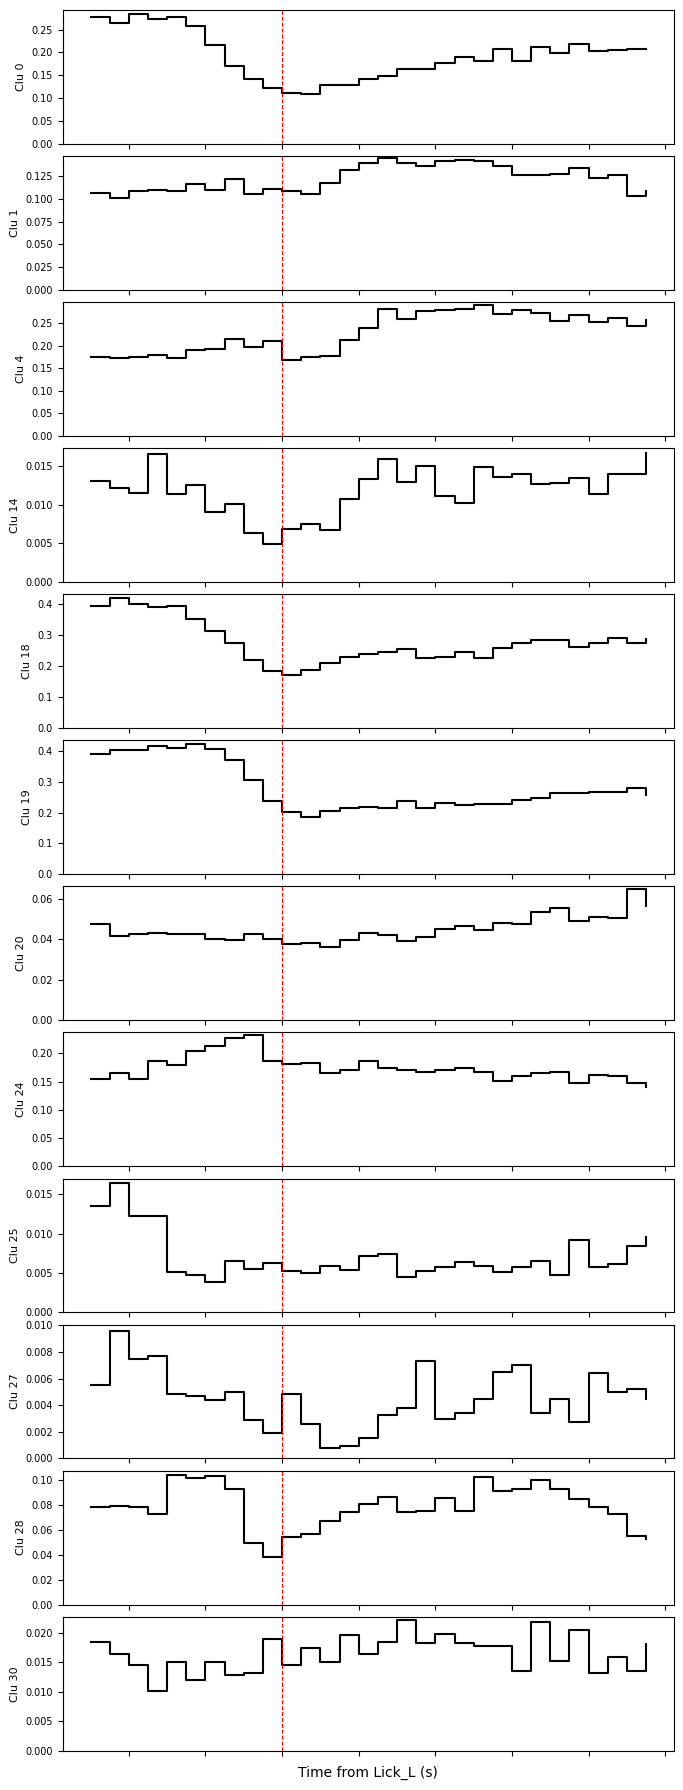

In [118]:
# List available NI_events fields for selection
print("Available NI_events fields:", ni.dtype.names)

# Set the event field to align to (edit this string to your desired event)
event_field = 'Lick_L'  # e.g., 'Baseline_ON', 'Change_ON', 'Lick_L', 'Lick_R', etc.

# Extract event times, handling nested fields (e.g., 'rise_t')
event_arr = ni[event_field]
if isinstance(event_arr, np.ndarray) and event_arr.size == 1 and hasattr(event_arr[0], 'dtype') and event_arr[0].dtype.names:
    # Nested struct, check for 'rise_t' or use all values
    subfields = event_arr[0].dtype.names
    print(f"{event_field} subfields:", subfields)
    if 'rise_t' in subfields:
        rise_t = event_arr[0]['rise_t']
        if isinstance(rise_t, np.ndarray) and rise_t.size == 1 and isinstance(rise_t[0], np.ndarray):
            event_times = np.array(rise_t[0]).flatten()
        else:
            event_times = np.array(rise_t).flatten()
        print(f"Extracted {len(event_times)} '{event_field}::rise_t' event times.")
    else:
        event_times = np.array(event_arr[0]).flatten()
        print(f"Extracted {len(event_times)} '{event_field}' event times (no 'rise_t').")
else:
    event_times = np.array(event_arr).flatten()
    print(f"Extracted {len(event_times)} '{event_field}' event times (not nested).")

# Clean and convert event_times to numeric
import numbers
def to_numeric_array(arr):
    arr = np.array(arr).flatten()
    arr = [x for x in arr if isinstance(x, numbers.Number) and not isinstance(x, bool)]
    return np.array(arr, dtype=float)
event_times = to_numeric_array(event_times)


spike_times_sec = spike_times
event_times_sec = event_times

# Plot outline PSTHs for multiple clusters (screening view)
n_plot = min(12, len(good_clusters))
clusters_to_plot = good_clusters[:n_plot] if n_plot > 0 else np.unique(cluster_ids)[:12]

window = [-0.5, 1.0]
bin_size = 0.05
bins = np.arange(window[0], window[1] + bin_size, bin_size)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(n_plot, 1, figsize=(7, 1.5 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    all_counts = []
    for t in event_times_sec:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
    axes[i].step(bins[:-1], psth, where='post', color='k')
    axes[i].axvline(0, color='r', linestyle='--', lw=0.8)
    axes[i].set_ylabel(f'Clu {clu}', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_ylim(bottom=0)
    if i < n_plot - 1:
        axes[i].set_xticklabels([])
axes[-1].set_xlabel(f'Time from {event_field} (s)')
plt.tight_layout(h_pad=0.2)
plt.show()

- To change the event, edit the `event_field` variable in the code cell above.
- The code will automatically handle nested fields (e.g., 'rise_t') if present.
- Rerun the cell to update the PSTH plots for your selected event.

In [90]:
# Robust event time extraction for any nested NI_events field
event_field = 'Baseline_ON'  # e.g., 'Baseline_ON', 'Change_ON', 'Lick_L', etc.
event_subfield = 'rise_t'    # e.g., 'rise_t', or None for flat arrays

event_arr = ni[event_field]
event_times = None

# Handle extra array nesting for MATLAB structs
if event_subfield and isinstance(event_arr, np.ndarray) and event_arr.size == 1 and hasattr(event_arr[0], 'dtype') and event_subfield in event_arr[0].dtype.names:
    subfield_arr = event_arr[0][event_subfield]
    if isinstance(subfield_arr, np.ndarray) and subfield_arr.size == 1 and isinstance(subfield_arr[0], np.ndarray):
        event_times = np.array(subfield_arr[0]).flatten()
    else:
        event_times = np.array(subfield_arr).flatten()
elif isinstance(event_arr, np.ndarray) and event_arr.size == 1 and isinstance(event_arr[0], np.ndarray):
    event_times = np.array(event_arr[0]).flatten()
else:
    event_times = np.array(event_arr).flatten()

# Clean and convert event_times to numeric
import numbers
def to_numeric_array(arr):
    arr = np.array(arr).flatten()
    arr = [x for x in arr if isinstance(x, numbers.Number) and not isinstance(x, bool)]
    return np.array(arr, dtype=float)
event_times = to_numeric_array(event_times)

# Convert to seconds if needed
if np.max(spike_times) > 1000 and len(event_times) > 0:
    spike_times_sec = spike_times / sample_rate
    event_times_sec = event_times / sample_rate
else:
    spike_times_sec = spike_times
    event_times_sec = event_times

field_str = event_subfield if event_subfield else "<none>"
print(f'Extracted {len(event_times)} event times for {event_field}::{field_str}')
print('First 10 event times (s):', event_times_sec[:10])

Extracted 1011 event times for Baseline_ON::rise_t
First 10 event times (s): [0.00163763 0.0017935  0.00225228 0.00261595 0.00301973 0.0035098
 0.00389901 0.00426778 0.00486886 0.0051571 ]


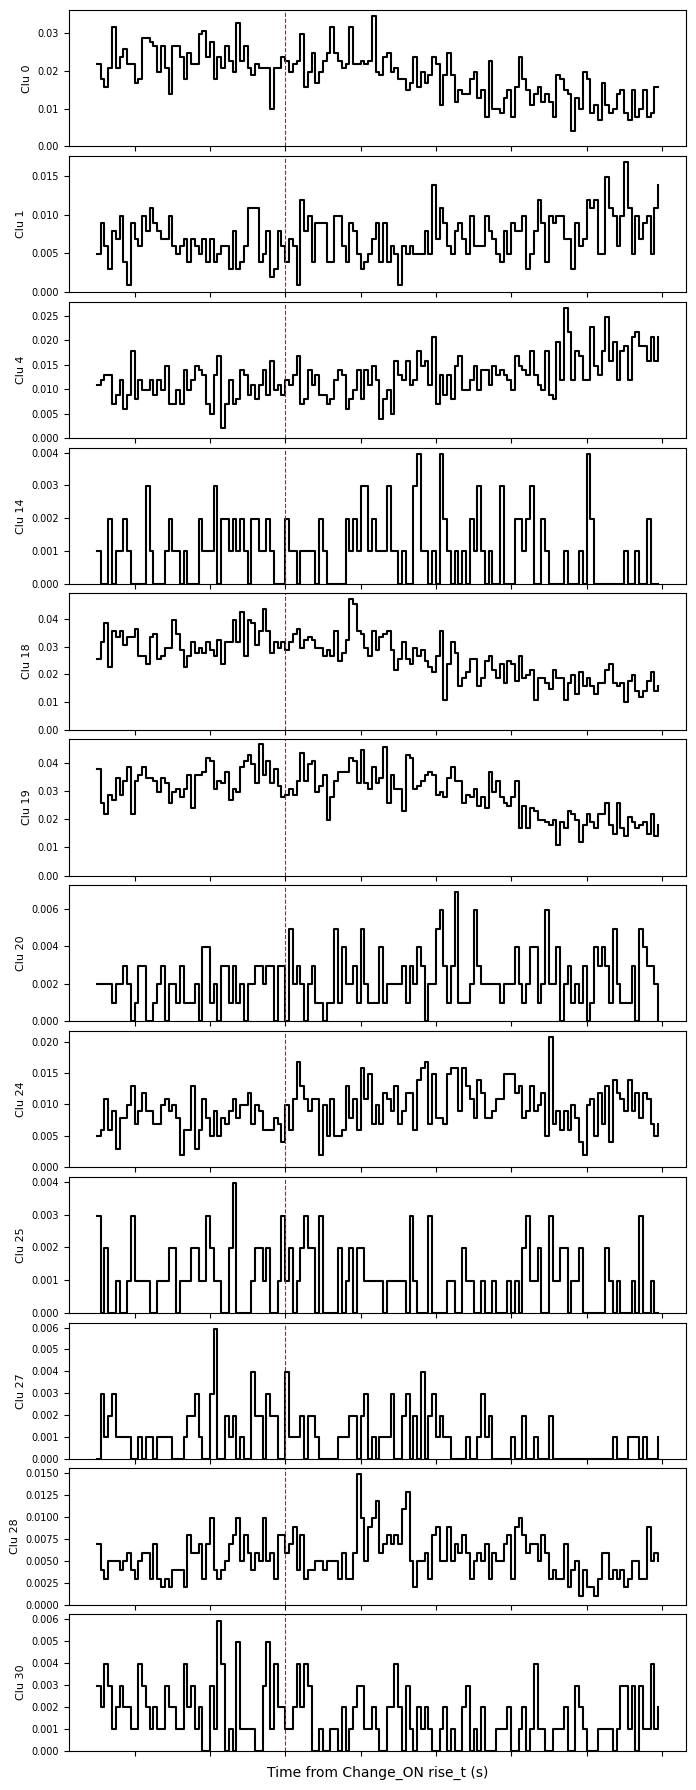

In [114]:
# --- Select event for alignment ---
event_field = 'Change_ON'  # Change to your desired event
event_subfield = 'rise_t'    # Change to None if not needed (e.g., for flat arrays)

# --- Extract event times robustly, handling extra array nesting ---
event_arr = ni[event_field]
event_times = None
if event_subfield and isinstance(event_arr, np.ndarray) and event_arr.size == 1 and hasattr(event_arr[0], 'dtype') and event_subfield in event_arr[0].dtype.names:
    subfield_arr = event_arr[0][event_subfield]
    # If subfield_arr is an array of length 1 and its first element is an array, extract it
    if isinstance(subfield_arr, np.ndarray) and subfield_arr.size == 1 and isinstance(subfield_arr[0], np.ndarray):
        event_times = np.array(subfield_arr[0]).flatten()
    else:
        event_times = np.array(subfield_arr).flatten()
elif isinstance(event_arr, np.ndarray) and event_arr.size == 1 and isinstance(event_arr[0], np.ndarray):
    # If event_arr is an array of length 1 and its first element is an array, extract it
    event_times = np.array(event_arr[0]).flatten()
else:
    event_times = np.array(event_arr).flatten()

# --- Clean and convert event_times to numeric ---
import numbers
def to_numeric_array(arr):
    arr = np.array(arr).flatten()
    arr = [x for x in arr if isinstance(x, numbers.Number) and not isinstance(x, bool)]
    return np.array(arr, dtype=float)
event_times = to_numeric_array(event_times)

# --- Convert to seconds if needed ---

spike_times_sec = spike_times
event_times_sec = event_times

# --- Plot PSTHs for multiple clusters ---
window = [-0.5, 1.0]  # Change as needed
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)
n_plot = min(12, len(good_clusters))
clusters_to_plot = good_clusters[:n_plot] if n_plot > 0 else np.unique(cluster_ids)[:12]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(n_plot, 1, figsize=(7, 1.5 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]
for i, clu in enumerate(clusters_to_plot):
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    all_counts = []
    for t in event_times_sec:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=bins)
        all_counts.append(counts)
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
    axes[i].step(bins[:-1], psth, where='post', color='k')
    axes[i].axvline(0, color='r', linestyle='--', lw=0.8)
    axes[i].set_ylabel(f'Clu {clu}', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_ylim(bottom=0)
    if i < n_plot - 1:
        axes[i].set_xticklabels([])
axes[-1].set_xlabel(f'Time from {event_field} {event_subfield or ""} (s)')
plt.tight_layout(h_pad=0.2)
plt.show()

In [87]:
# Diagnostic: Check overlap and windowed spike counts for selected event and clusters

print("Number of spikes (all clusters):", len(spike_times_sec))
print("Number of events:", len(event_times_sec))
print("Spike times (s): min =", np.min(spike_times_sec) if len(spike_times_sec) else None, 
      ", max =", np.max(spike_times_sec) if len(spike_times_sec) else None)
print("Event times (s): min =", np.min(event_times_sec) if len(event_times_sec) else None, 
      ", max =", np.max(event_times_sec) if len(event_times_sec) else None)
print("First 10 spike times (s):", spike_times_sec[:10])
print("First 10 event times (s):", event_times_sec[:10])

# Check if any spikes fall within the window for the first 10 events, for the first 3 clusters
window = [-0.5, 1.0]  # Use the same window as your PSTH
for clu in good_clusters[:3]:
    spike_times_clu = spike_times_sec[cluster_ids == clu]
    print(f"\nCluster {clu}:")
    for i, t in enumerate(event_times_sec[:10]):
        aligned = spike_times_clu - t
        in_window = np.sum((aligned >= window[0]) & (aligned <= window[1]))
        print(f"  Event {i}: {in_window} spikes in window [{window[0]}, {window[1]}] s")

Number of spikes (all clusters): 19903845
Number of events: 0
Spike times (s): min = 0.0030666666666666668 , max = 12882.977833333332
Event times (s): min = None , max = None
First 10 spike times (s): [0.00306667 0.00346667 0.00376667 0.0083     0.00886667 0.0098
 0.01023333 0.0119     0.01233333 0.01286667]
First 10 event times (s): []

Cluster 0:

Cluster 1:

Cluster 4:


In [92]:
# Diagnostic: Check raw event times and their range
print('Raw event_times (first 10):', event_times[:10])
print('Raw event_times (min, max):', np.min(event_times), np.max(event_times))
print('Session duration (spike_times, s):', np.min(spike_times), np.max(spike_times))
print('Sample rate:', sample_rate)

# If event_times are in samples, dividing by sample_rate should bring them into the same range as spike_times
if np.max(event_times) > 1000:
    print('Event times are likely in samples or ms, not seconds.')
else:
    print('Event times are already small; check if they match the spike_times range.')

Raw event_times (first 10): [ 49.1289696  53.8050736  67.5683104  78.478496   90.5918096 105.2940432
 116.9702848 128.0334928 146.0658752 154.7130096]
Raw event_times (min, max): 49.1289695999214 12866.051175979415
Session duration (spike_times, s): 0.0030666666666666668 12882.977833333332
Sample rate: 30000
Event times are likely in samples or ms, not seconds.


- Change `event_field` and `event_subfield` at the top of the cell to select your event and subfield (e.g., 'Baseline_ON', 'rise_t').
- The window variable controls how much time before and after the event is shown.
- This will plot the PSTH for multiple clusters, showing both pre- and post-event activity.

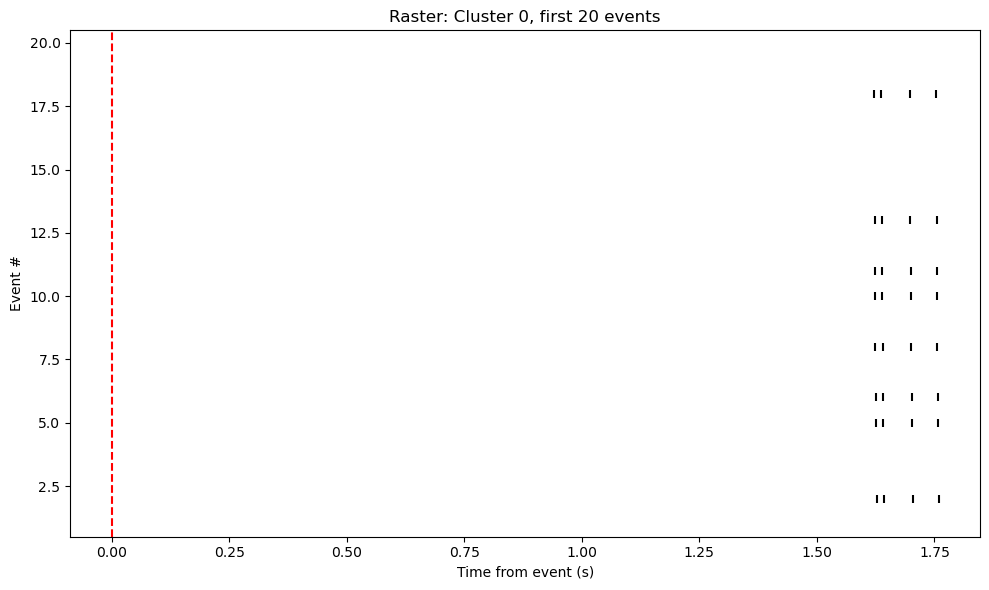

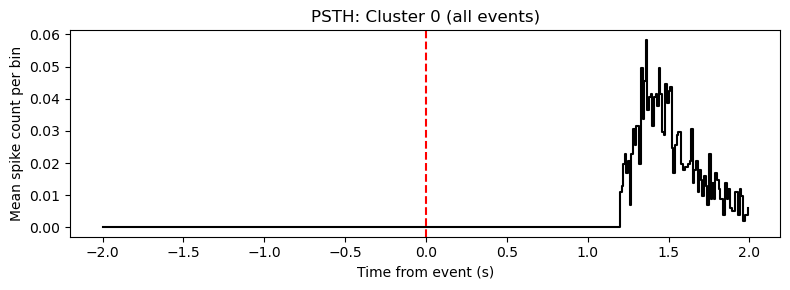

In [112]:
# Diagnostic: Plot raster and PSTH for a single cluster and a few events

import matplotlib.pyplot as plt

cluster_idx = 0  # Change to index of a cluster you want to check
clu = good_clusters[cluster_idx]
spike_times_clu = spike_times[cluster_ids == clu]

# Pick a few events to visualize
n_events_to_plot = 20
events_to_plot = event_times_sec[:n_events_to_plot]
window = [-2.0, 2.0]
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)

# Raster plot
plt.figure(figsize=(10, 6))
for i, t in enumerate(events_to_plot):
    aligned = spike_times_clu - t
    spikes_in_window = aligned[(aligned >= window[0]) & (aligned <= window[1])]
    plt.scatter(spikes_in_window, np.full_like(spikes_in_window, i + 1), marker='|', color='k', s=30)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Time from event (s)')
plt.ylabel('Event #')
plt.title(f'Raster: Cluster {clu}, first {n_events_to_plot} events')
plt.ylim(0.5, n_events_to_plot + 0.5)
plt.tight_layout()
plt.show()

# PSTH for this cluster, all events
all_counts = []
for t in event_times_sec:
    aligned = spike_times_clu - t
    counts, _ = np.histogram(aligned, bins=bins)
    all_counts.append(counts)
psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)

plt.figure(figsize=(8, 3))
plt.step(bins[:-1], psth, where='post', color='k')
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Time from event (s)')
plt.ylabel('Mean spike count per bin')
plt.title(f'PSTH: Cluster {clu} (all events)')
plt.tight_layout()
plt.show()

In [105]:
# Raster and PSTH diagnostic for a single cluster and a few events

import matplotlib.pyplot as plt

# Choose a cluster to inspect
cluster_idx = 0  # Change this index to inspect other clusters
clu = good_clusters[cluster_idx]
spike_times_clu = spike_times_sec[cluster_ids == clu]

# Pick a few events to visualize
n_events_to_plot = 20
window = [-2.0, 2.0]
bin_size = 0.01
bins = np.arange(window[0], window[1] + bin_size, bin_size)
events_to_plot = event_times_sec[:n_events_to_plot]

# Raster plot: each row is spikes aligned to one event
plt.figure(figsize=(10, 6))
for i, t in enumerate(events_to_plot):
    aligned = spike_times_clu - t
    spikes_in_window = aligned[(aligned >= window[0]) & (aligned <= window[1])]
    plt.scatter(spikes_in_window, np.full_like(spikes_in_window, i + 1), marker='|', color='k', s=30)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Time from event (s)')
plt.ylabel('Event #')
plt.title(f'Raster: Cluster {clu}, first {n_events_to_plot} events')
plt.ylim(0.5, n_events_to_plot + 0.5)
plt.tight_layout()
plt.show()

# PSTH for this cluster, all events
all_counts = []
for t in event_times_sec:
    aligned = spike_times_clu - t
    counts, _ = np.histogram(aligned, bins=bins)
    all_counts.append(counts)
psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)

plt.figure(figsize=(8, 3))
plt.step(bins[:-1], psth, where='post', color='k')
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Time from event (s)')
plt.ylabel('Mean spike count per bin')
plt.title(f'PSTH: Cluster {clu} (all events)')
plt.tight_layout()
plt.show()

In [107]:
# Diagnostic: Check spike alignment for raster

cluster_idx = 0  # Same as in raster cell
clu = good_clusters[cluster_idx]
spike_times_clu = spike_times_sec[cluster_ids == clu]

n_events_to_plot = 20
window = [-2.0, 2.0]
events_to_plot = event_times_sec[:n_events_to_plot]

print(f"Cluster {clu}: {len(spike_times_clu)} spikes in total")
for i, t in enumerate(events_to_plot):
    aligned = spike_times_clu - t
    spikes_in_window = aligned[(aligned >= window[0]) & (aligned <= window[1])]
    print(f"Event {i}: {len(spikes_in_window)} spikes in window, first 10 aligned times: {spikes_in_window[:10]}")

Cluster 0: 64555 spikes in total
Event 0: 0 spikes in window, first 10 aligned times: []
Event 1: 64555 spikes in window, first 10 aligned times: [-0.00196587 -0.00196536 -0.00196332 -0.00196148 -0.00195122 -0.00191228
 -0.00184622 -0.00184522 -0.00183914 -0.00183462]
Event 2: 0 spikes in window, first 10 aligned times: []
Event 3: 0 spikes in window, first 10 aligned times: []
Event 4: 64555 spikes in window, first 10 aligned times: [-0.0032571  -0.00325658 -0.00325455 -0.0032527  -0.00324244 -0.00320351
 -0.00313745 -0.00313644 -0.00313037 -0.00312584]
Event 5: 64555 spikes in window, first 10 aligned times: [-0.00367217 -0.00367166 -0.00366962 -0.00366777 -0.00365751 -0.00361858
 -0.00355252 -0.00355152 -0.00354544 -0.00354092]
Event 6: 0 spikes in window, first 10 aligned times: []
Event 7: 64555 spikes in window, first 10 aligned times: [-0.00452515 -0.00452464 -0.00452261 -0.00452076 -0.0045105  -0.00447156
 -0.00440551 -0.0044045  -0.00439842 -0.0043939 ]
Event 8: 0 spikes in wi

In [108]:
# Check differences between consecutive event times
event_diffs = np.diff(event_times_sec)
print("First 20 event time diffs (s):", event_diffs[:20])
print("Min/Max event time diff (s):", np.min(event_diffs), np.max(event_diffs))

# Check spike time range
print("Spike times (s): min =", np.min(spike_times_sec), ", max =", np.max(spike_times_sec))
print("First 20 spike times (s):", spike_times_sec[:20])


First 20 event time diffs (s): [       nan        nan        nan        nan 0.00041507        nan
        nan        nan        nan 0.00044648        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan]
Min/Max event time diff (s): nan nan
Spike times (s): min = 1.0222222222222223e-07 , max = 0.4294325944444444
First 20 spike times (s): [1.02222222e-07 1.15555556e-07 1.25555556e-07 2.76666667e-07
 2.95555556e-07 3.26666667e-07 3.41111111e-07 3.96666667e-07
 4.11111111e-07 4.28888889e-07 5.13333333e-07 5.20000000e-07
 5.25555556e-07 5.48888889e-07 5.58888889e-07 5.71111111e-07
 6.41111111e-07 6.68888889e-07 7.03333333e-07 7.26666667e-07]


In [109]:
print("Raw spike_times (first 10):", spike_times[:10]) print("Raw spike_times (min, max):", np.min(spike_times), np.max(spike_times)) print("Sample rate:", sample_rate)

SyntaxError: invalid syntax (3612494994.py, line 1)

In [111]:
# Use spike_times directly as seconds
spike_times_sec = spike_times  # Already in seconds, do NOT divide by sample_rate

# Now re-run your raster and PSTH plotting cells using spike_times_sec
print("spike_times_sec (first 10):", spike_times_sec[:10])
print("spike_times_sec (min, max):", np.min(spike_times_sec), np.max(spike_times_sec))
print("event_times_sec (first 10):", event_times_sec[:10])
print("event_times_sec (min, max):", np.min(event_times_sec), np.max(event_times_sec))

spike_times_sec (first 10): [0.00306667 0.00346667 0.00376667 0.0083     0.00886667 0.0098
 0.01023333 0.0119     0.01233333 0.01286667]
spike_times_sec (min, max): 0.0030666666666666668 12882.977833333332
event_times_sec (first 10): [       nan 0.00202017        nan        nan 0.0033114  0.00372647
        nan 0.00457945        nan 0.0053871 ]
event_times_sec (min, max): nan nan
